In [5]:
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import urllib, PIL
import numpy as np
import cv2

In [6]:
img=load_img('adolf.jpg')

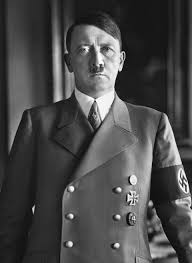

In [7]:
img

In [8]:
type(img)

PIL.JpegImagePlugin.JpegImageFile

In [9]:
img_to_array(img)

array([[[32., 32., 32.],
        [30., 30., 30.],
        [27., 27., 27.],
        ...,
        [49., 49., 49.],
        [60., 60., 60.],
        [67., 67., 67.]],

       [[32., 32., 32.],
        [30., 30., 30.],
        [27., 27., 27.],
        ...,
        [49., 49., 49.],
        [60., 60., 60.],
        [67., 67., 67.]],

       [[32., 32., 32.],
        [30., 30., 30.],
        [27., 27., 27.],
        ...,
        [49., 49., 49.],
        [60., 60., 60.],
        [67., 67., 67.]],

       ...,

       [[27., 27., 27.],
        [28., 28., 28.],
        [29., 29., 29.],
        ...,
        [62., 62., 62.],
        [74., 74., 74.],
        [81., 81., 81.]],

       [[28., 28., 28.],
        [28., 28., 28.],
        [29., 29., 29.],
        ...,
        [58., 58., 58.],
        [73., 73., 73.],
        [82., 82., 82.]],

       [[28., 28., 28.],
        [29., 29., 29.],
        [29., 29., 29.],
        ...,
        [56., 56., 56.],
        [72., 72., 72.],
        [82., 82., 82.]]

In [10]:
img=img_to_array(img)

In [11]:
img.shape

(263, 192, 3)

In [12]:
img=cv2.resize(img,(224,224))

In [13]:
img.shape

(224, 224, 3)

In [14]:
#preprocess the image
img=preprocess_input(img)

In [15]:
help(ResNet50)

Help on function ResNet50 in module keras.src.applications.resnet:

ResNet50(include_top=True, weights='imagenet', input_tensor=None, input_shape=None, pooling=None, classes=1000, classifier_activation='softmax', name='resnet50')
    Instantiates the ResNet50 architecture.

    Reference:
    - [Deep Residual Learning for Image Recognition](
        https://arxiv.org/abs/1512.03385) (CVPR 2015)

    For image classification use cases, see [this page for detailed examples](
        https://keras.io/api/applications/#usage-examples-for-image-classification-models).

    For transfer learning use cases, make sure to read the
    [guide to transfer learning & fine-tuning](
        https://keras.io/guides/transfer_learning/).

    Note: each Keras Application expects a specific kind of input preprocessing.
    For ResNet, call `keras.applications.resnet.preprocess_input` on your
    inputs before passing them to the model. `resnet.preprocess_input` will convert
    the input images from RGB

In [16]:
model=ResNet50()

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [17]:
result=model.predict(img.reshape(1,224,224,3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [18]:
result

array([[9.80495685e-08, 1.49776028e-07, 1.61120124e-06, 6.18482602e-07,
        3.59640268e-07, 1.16975094e-07, 4.15021120e-08, 3.68123608e-07,
        4.46937349e-08, 1.18501635e-08, 5.85773883e-08, 7.07092829e-09,
        9.81535138e-08, 4.17671906e-08, 6.84930246e-09, 1.72679918e-07,
        8.63743495e-08, 7.54763434e-08, 8.54169215e-08, 2.63147175e-08,
        8.07054246e-09, 4.93756602e-07, 5.21252588e-08, 3.46104336e-08,
        9.37765279e-08, 2.07287751e-08, 1.62863163e-08, 3.79998788e-08,
        3.77129510e-07, 1.36598652e-08, 9.08047753e-08, 2.27587247e-08,
        4.44876633e-08, 1.80307907e-07, 7.51157216e-08, 5.73858960e-09,
        1.76136624e-07, 2.13391456e-08, 5.73744323e-08, 8.42964454e-08,
        1.41005160e-07, 2.01918979e-08, 2.68829448e-09, 9.54830384e-08,
        5.75544057e-08, 1.85665328e-07, 6.06989587e-08, 1.38342822e-08,
        3.45930786e-08, 5.91909526e-08, 4.07594420e-08, 9.86212967e-07,
        4.09993568e-08, 9.55573682e-08, 4.62228741e-07, 1.035024

In [19]:
decode_predictions(result)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n04350905', 'suit', np.float32(0.5779806)),
  ('n04591157', 'Windsor_tie', np.float32(0.15684591)),
  ('n03763968', 'military_uniform', np.float32(0.14228725)),
  ('n04479046', 'trench_coat', np.float32(0.046853833)),
  ('n02883205', 'bow_tie', np.float32(0.040711783))]]

In [20]:
url='https://cdn.britannica.com/24/92724-050-54648BED/Scorpion.jpg'
img=np.array(PIL.Image.open(urllib.request.urlopen(url)))
img=img_to_array(img)
img=cv2.resize(img,(224,224))
img=preprocess_input(img)
result=model.predict(img.reshape(1,224,224,3))
decode_predictions(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


[[('n01770393', 'scorpion', np.float32(0.99975556)),
  ('n01677366', 'common_iguana', np.float32(7.644796e-05)),
  ('n01985128', 'crayfish', np.float32(2.9791516e-05)),
  ('n01687978', 'agama', np.float32(2.609508e-05)),
  ('n01978455', 'rock_crab', np.float32(2.2808514e-05))]]

In [21]:
from keras.utils import plot_model

In [22]:
plot_model(model, show_layer_activations=True, show_layer_names=True,
           show_shapes=True, show_trainable=True, show_dtype=True)